In [61]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install & Imports
# ═══════════════════════════════════════════════════════════════
!pip install -q albumentations ultralytics

import os, gc, json, time, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import defaultdict, Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

warnings.filterwarnings('ignore')
DEVICE  = 0 if torch.cuda.is_available() else 'cpu'
DEV_STR = 'cuda' if torch.cuda.is_available() else 'cpu'
gc.collect(); torch.cuda.empty_cache()
print(f'Device : {DEV_STR}')
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'GPU free  : {free/1e9:.2f} GB / {total/1e9:.2f} GB')
print('✅ Imports done')

Device : cuda
GPU free  : 11.61 GB / 15.64 GB
✅ Imports done


In [62]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Paths, Data & Constants
# ═══════════════════════════════════════════════════════════════
RAW_DIR   = Path('/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection')
OUT_DIR   = Path('/kaggle/working/processed')
MODEL_DIR = Path('/kaggle/working/models');   MODEL_DIR.mkdir(exist_ok=True)
M3_OUT    = Path('/kaggle/working/milestone3'); M3_OUT.mkdir(exist_ok=True)
VAL_PNG   = OUT_DIR / 'images' / 'val'
DET_BASE  = Path('/kaggle/working/dataset')
DIMG_VAL  = DET_BASE / 'images' / 'val'
DLBL_VAL  = DET_BASE / 'labels' / 'val'
DET_YAML  = DET_BASE / 'config.yaml'

df = pd.read_csv(RAW_DIR / 'train.csv')
PATHOLOGY_CLASSES = sorted([c for c in df['class_name'].unique() if c != 'No finding'])
NUM_CLASSES       = len(PATHOLOGY_CLASSES)
train_df = pd.read_csv(OUT_DIR / 'train_labels.csv')
val_df   = pd.read_csv(OUT_DIR / 'val_labels.csv')

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
# Memory-safe defaults
BATCH_SIZE = 4
IMG_SIZE   = 320

print(f'Classes : {NUM_CLASSES}')
print(f'Train   : {len(train_df):,}   Val: {len(val_df):,}')
print('✅ Data loaded')

Classes : 14
Train   : 1,600   Val: 400
✅ Data loaded


In [63]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — All Shared Functions (run once after every restart)
# ═══════════════════════════════════════════════════════════════

# ── Dataset ───────────────────────────────────────────────────
class VinDrDataset(Dataset):
    def __init__(self, df, pathology_classes, transform=None):
        self.df = df.reset_index(drop=True)
        self.classes = pathology_classes
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform: img = self.transform(img)
        label = torch.tensor([float(row[c]) for c in self.classes], dtype=torch.float32)
        return img, label

class VinDrAlbuDataset(Dataset):
    """Albumentations version."""
    def __init__(self, df, pathology_classes, transform=None):
        self.df = df.reset_index(drop=True)
        self.classes = pathology_classes
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(row['image_path']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.tensor(img).permute(2,0,1).float()/255
        label = torch.tensor([float(row[c]) for c in self.classes], dtype=torch.float32)
        return img, label

# ── Transforms ────────────────────────────────────────────────
def make_transforms(img_size=320):
    train_tf = T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.ColorJitter(brightness=0.15, contrast=0.15),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    val_tf = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return train_tf, val_tf

def make_loaders(train_df, val_df, img_size=320, batch=4):
    train_tf, val_tf = make_transforms(img_size)
    tl = DataLoader(VinDrDataset(train_df, PATHOLOGY_CLASSES, train_tf),
                    batch_size=batch, shuffle=True,  num_workers=0, pin_memory=False)
    vl = DataLoader(VinDrDataset(val_df,   PATHOLOGY_CLASSES, val_tf),
                    batch_size=batch, shuffle=False, num_workers=0, pin_memory=False)
    return tl, vl

# ── Model builders ────────────────────────────────────────────
def _clf_head(in_f, num_classes, dropout=0.3):
    return nn.Sequential(
        nn.Dropout(p=dropout), nn.Linear(in_f, 512),
        nn.ReLU(inplace=True), nn.Dropout(p=dropout/2),
        nn.Linear(512, num_classes)
    )

def build_model(backbone='efficientnet_b3', num_classes=14, dropout=0.3):
    if backbone == 'efficientnet_b3':
        m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        m.classifier = _clf_head(m.classifier[1].in_features, num_classes, dropout)
    elif backbone == 'efficientnet_b2':
        m = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        m.classifier = _clf_head(m.classifier[1].in_features, num_classes, dropout)
    elif backbone == 'densenet121':
        m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        m.classifier = _clf_head(m.classifier.in_features, num_classes, dropout)
    elif backbone == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        m.fc = _clf_head(m.fc.in_features, num_classes, dropout)
    return m

def unfreeze_last(model, n=20):
    params = list(model.parameters())
    for p in params[:-n]: p.requires_grad = False
    for p in params[-n:]: p.requires_grad = True
    print(f'Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    return model

def get_criterion(train_df, device):
    pos = train_df[PATHOLOGY_CLASSES].sum().values.astype(np.float32)
    neg = len(train_df) - pos
    pw  = torch.tensor(neg/(pos+1e-6), dtype=torch.float32).to(device)
    return nn.BCEWithLogitsLoss(pos_weight=pw)

# ── Train / Eval one epoch ────────────────────────────────────
scaler = GradScaler()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); total = 0.0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            loss = criterion(model(imgs), lbls)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        total += loss.item(); del imgs, lbls
    return total / len(loader)

def eval_one_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval(); v_loss, all_p, all_l = 0.0, [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            with autocast(): logits = model(imgs)
            v_loss += criterion(logits, lbls).item()
            all_p.append(torch.sigmoid(logits).cpu().numpy())
            all_l.append(lbls.cpu().numpy()); del imgs, lbls
    all_p = np.vstack(all_p); all_l = np.vstack(all_l)
    preds = (all_p >= threshold).astype(int)
    aucs  = [roc_auc_score(all_l[:,i], all_p[:,i]) for i in range(NUM_CLASSES) if all_l[:,i].sum()>0]
    auc   = float(np.mean(aucs)) if aucs else 0.0
    f1    = f1_score(all_l, preds, average='macro', zero_division=0)
    return v_loss/len(loader), auc, f1, all_p, all_l

# ── Quick experiment runner ───────────────────────────────────
def run_clf_experiment(cfg, train_df, val_df, epochs=5):
    gc.collect(); torch.cuda.empty_cache()
    tl, vl = make_loaders(train_df, val_df, img_size=cfg.get('img_size',320), batch=cfg.get('batch',4))
    model  = build_model(cfg.get('backbone','efficientnet_b3'), NUM_CLASSES).to(DEV_STR)
    crit   = get_criterion(train_df, DEV_STR)
    opt_name = cfg.get('optimizer','AdamW')
    if opt_name == 'AdamW': opt = optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    elif opt_name == 'Adam': opt = optim.Adam(model.parameters(), lr=cfg['lr'])
    elif opt_name == 'SGD':  opt = optim.SGD(model.parameters(),  lr=cfg['lr'], momentum=0.9, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    best_auc = 0.0
    for ep in range(1, epochs+1):
        tl_ = train_one_epoch(model, tl, opt, crit, DEV_STR)
        _, auc, f1, _, _ = eval_one_epoch(model, vl, crit, DEV_STR)
        sch.step()
        if auc > best_auc: best_auc = auc
        print(f'  Ep{ep}/{epochs} | AUC={auc:.4f} | F1={f1:.4f} | Loss={tl_:.4f}')
    gc.collect(); torch.cuda.empty_cache()
    return best_auc, f1

print('✅ All shared functions defined')

✅ All shared functions defined


In [64]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Classification Hyperparameter Tuning
# 5 epochs each for fast comparison
# ═══════════════════════════════════════════════════════════════
EXP_EPOCHS = 5

experiments = [
    {'name': 'Baseline  AdamW lr=1e-4 bs=4',  'lr':1e-4, 'batch':4, 'optimizer':'AdamW'},
    {'name': 'High LR   AdamW lr=5e-4',        'lr':5e-4, 'batch':4, 'optimizer':'AdamW'},
    {'name': 'Low LR    AdamW lr=5e-5',        'lr':5e-5, 'batch':4, 'optimizer':'AdamW'},
    {'name': 'Adam      lr=1e-4',              'lr':1e-4, 'batch':4, 'optimizer':'Adam'},
    {'name': 'SGD       lr=1e-3',              'lr':1e-3, 'batch':4, 'optimizer':'SGD'},
    {'name': 'Large bs  AdamW bs=8',           'lr':1e-4, 'batch':8, 'optimizer':'AdamW'},
]

clf_exp_results = []
print('='*60)
print('  CLASSIFICATION HYPERPARAMETER EXPERIMENTS')
print('='*60)

for cfg in experiments:
    print(f'\n▶ {cfg["name"]}')
    best_auc, best_f1 = run_clf_experiment(cfg, train_df, val_df, EXP_EPOCHS)
    clf_exp_results.append({
        'Experiment': cfg['name'], 'Optimizer': cfg['optimizer'],
        'LR': cfg['lr'], 'Batch': cfg['batch'],
        'Best AUC': round(best_auc,4), 'Best F1': round(best_f1,4)
    })

clf_exp_df = pd.DataFrame(clf_exp_results).sort_values('Best AUC', ascending=False)
print('\n' + '='*60)
print('  RESULTS TABLE')
print('='*60)
print(clf_exp_df.to_string(index=False))
clf_exp_df.to_csv(str(M3_OUT/'clf_hyperparam_results.csv'), index=False)
print('\n✅ clf_hyperparam_results.csv saved')

  CLASSIFICATION HYPERPARAMETER EXPERIMENTS

▶ Baseline  AdamW lr=1e-4 bs=4
  Ep1/5 | AUC=0.8974 | F1=0.3256 | Loss=1.7669
  Ep2/5 | AUC=0.8942 | F1=0.3245 | Loss=1.6008
  Ep3/5 | AUC=0.9072 | F1=0.3482 | Loss=1.7823
  Ep4/5 | AUC=0.9186 | F1=0.3735 | Loss=1.4147
  Ep5/5 | AUC=0.9173 | F1=0.3762 | Loss=1.3086

▶ High LR   AdamW lr=5e-4
  Ep1/5 | AUC=0.8033 | F1=0.1647 | Loss=2.2295
  Ep2/5 | AUC=0.8841 | F1=0.3508 | Loss=2.1497
  Ep3/5 | AUC=0.9155 | F1=0.3331 | Loss=1.6491
  Ep4/5 | AUC=0.9176 | F1=0.3896 | Loss=1.3229
  Ep5/5 | AUC=0.9161 | F1=0.3971 | Loss=1.2069

▶ Low LR    AdamW lr=5e-5
  Ep1/5 | AUC=0.8846 | F1=0.3086 | Loss=1.5028
  Ep2/5 | AUC=0.9024 | F1=0.3203 | Loss=1.4950
  Ep3/5 | AUC=0.9110 | F1=0.3418 | Loss=1.3029
  Ep4/5 | AUC=0.9143 | F1=0.3504 | Loss=1.3207
  Ep5/5 | AUC=0.9177 | F1=0.3502 | Loss=1.2622

▶ Adam      lr=1e-4
  Ep1/5 | AUC=0.8994 | F1=0.3180 | Loss=1.5873
  Ep2/5 | AUC=0.9105 | F1=0.3164 | Loss=1.6340
  Ep3/5 | AUC=0.9140 | F1=0.3627 | Loss=1.5730
  E

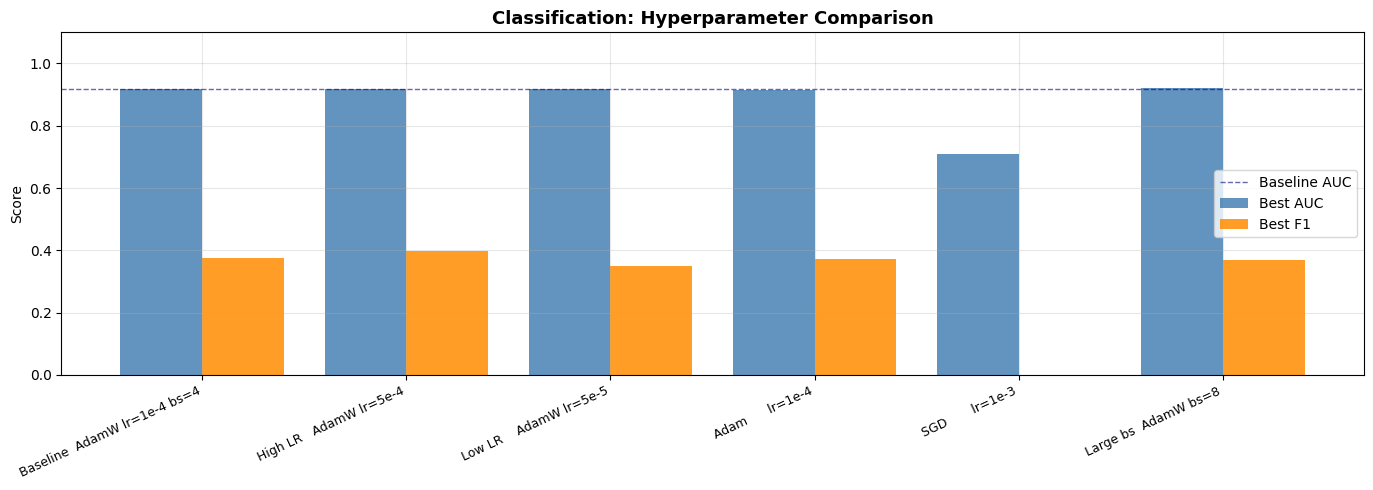

✅ clf_hyperparam_comparison.png saved


In [65]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Plot Classification Comparison
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
x      = range(len(clf_exp_results))
labels = [r['Experiment'][:30] for r in clf_exp_results]
aucs   = [r['Best AUC'] for r in clf_exp_results]
f1s    = [r['Best F1']  for r in clf_exp_results]

ax.bar(x,           aucs, width=0.4, label='Best AUC', color='steelblue', alpha=0.85)
ax.bar([i+0.4 for i in x], f1s, width=0.4, label='Best F1', color='darkorange', alpha=0.85)
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.axhline(clf_exp_results[0]['Best AUC'], linestyle='--', color='navy',
           linewidth=1, alpha=0.6, label='Baseline AUC')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylabel('Score')
ax.set_title('Classification: Hyperparameter Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(str(M3_OUT/'clf_hyperparam_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ clf_hyperparam_comparison.png saved')

In [66]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — YOLO Hyperparameter Experiments
# ═══════════════════════════════════════════════════════════════
yolo_configs = [
    {'name':'Baseline  lr=1e-3 bs=8 conf=0.15',  'lr0':1e-3, 'batch':8,  'conf':0.15, 'iou':0.45},
    {'name':'High LR   lr=5e-3',                  'lr0':5e-3, 'batch':8,  'conf':0.15, 'iou':0.45},
    {'name':'Low LR    lr=5e-4',                  'lr0':5e-4, 'batch':8,  'conf':0.15, 'iou':0.45},
    {'name':'Large bs  bs=16',                    'lr0':1e-3, 'batch':16, 'conf':0.15, 'iou':0.45},
    {'name':'Low conf  conf=0.10',                'lr0':1e-3, 'batch':8,  'conf':0.10, 'iou':0.45},
    {'name':'High IoU  iou=0.60',                 'lr0':1e-3, 'batch':8,  'conf':0.15, 'iou':0.60},
]

yolo_exp_results = []
print('='*60)
print('  YOLO HYPERPARAMETER EXPERIMENTS  (10 epochs each)')
print('='*60)

for i, cfg in enumerate(yolo_configs):
    print(f'\n▶ Experiment {i+1}: {cfg["name"]}')
    m = YOLO('yolov8m.pt')
    m.train(
        data=str(DET_YAML), epochs=10, imgsz=640,
        batch=cfg['batch'], name=f'yolo_hp_{i+1}',
        project='/kaggle/working/yolo_exps',
        device=DEVICE, workers=2, patience=5,
        optimizer='AdamW', lr0=cfg['lr0'], lrf=0.01,
        weight_decay=5e-4, warmup_epochs=2,
        box=9.0, cls=1.5, dfl=1.5,
        fliplr=0.5, flipud=0.0, degrees=10.0,
        translate=0.05, scale=0.1, hsv_v=0.1,
        hsv_h=0.0, hsv_s=0.0, mosaic=0.5,
        mixup=0.0, perspective=0.0, shear=0.0,
        iou=0.5, conf=0.001,
        save=True, plots=False, verbose=False
    )
    best_m = YOLO(f'/kaggle/working/yolo_exps/yolo_hp_{i+1}/weights/best.pt')
    vm = best_m.val(data=str(DET_YAML), imgsz=640, batch=8,
                    conf=cfg['conf'], iou=cfg['iou'],
                    device=DEVICE, verbose=False, split='val')
    yolo_exp_results.append({
        'Experiment': cfg['name'],
        'mAP@50':    round(float(vm.box.map50), 4),
        'mAP@50-95': round(float(vm.box.map),   4),
        'Precision': round(float(vm.box.mp),     4),
        'Recall':    round(float(vm.box.mr),     4),
        'LR': cfg['lr0'], 'Batch': cfg['batch'],
        'Conf': cfg['conf'], 'IoU': cfg['iou']
    })
    del m, best_m; gc.collect(); torch.cuda.empty_cache()

yolo_exp_df = pd.DataFrame(yolo_exp_results).sort_values('mAP@50', ascending=False)
print('\n' + '='*60)
print('  YOLO RESULTS TABLE')
print('='*60)
print(yolo_exp_df.to_string(index=False))
yolo_exp_df.to_csv(str(M3_OUT/'yolo_hyperparam_results.csv'), index=False)
print('\n✅ yolo_hyperparam_results.csv saved')

  YOLO HYPERPARAMETER EXPERIMENTS  (10 epochs each)

▶ Experiment 1: Baseline  lr=1e-3 bs=8 conf=0.15
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=9.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=0.001, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/config.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.1, imgsz=640, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolo_hp_1,

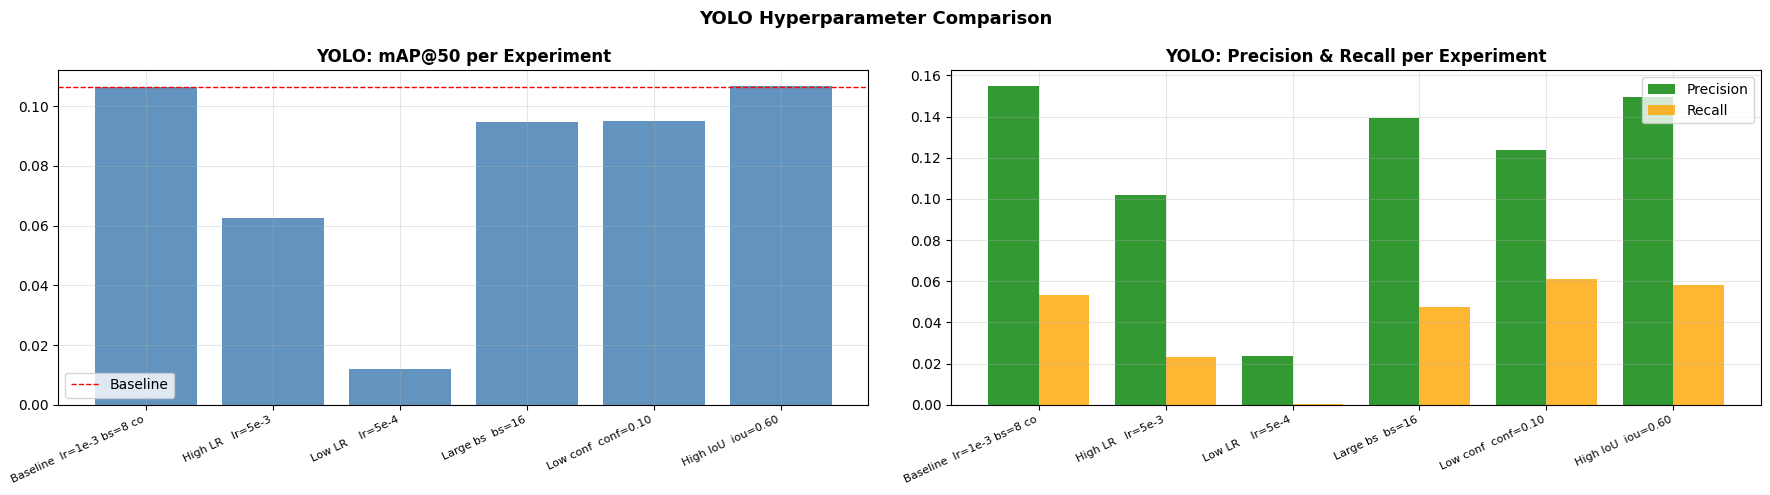

✅ yolo_hyperparam_comparison.png saved


In [67]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Plot YOLO Comparison
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
names = [r['Experiment'][:25] for r in yolo_exp_results]
x     = range(len(yolo_exp_results))

axes[0].bar(x, [r['mAP@50'] for r in yolo_exp_results], color='steelblue', alpha=0.85)
axes[0].axhline(yolo_exp_results[0]['mAP@50'], linestyle='--', color='red', linewidth=1, label='Baseline')
axes[0].set_title('YOLO: mAP@50 per Experiment', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=25, ha='right', fontsize=8)
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(x, [r['Precision'] for r in yolo_exp_results], width=0.4, label='Precision', color='green', alpha=0.8)
axes[1].bar([i+0.4 for i in x], [r['Recall'] for r in yolo_exp_results], width=0.4, label='Recall', color='orange', alpha=0.8)
axes[1].set_title('YOLO: Precision & Recall per Experiment', fontweight='bold')
axes[1].set_xticks([i+0.2 for i in x]); axes[1].set_xticklabels(names, rotation=25, ha='right', fontsize=8)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('YOLO Hyperparameter Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(M3_OUT/'yolo_hyperparam_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ yolo_hyperparam_comparison.png saved')

In [68]:
train_albu = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15,
                               contrast_limit=0.15, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.4),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE),
                        scale=(0.85, 1.0), p=0.3),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

val_albu = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

print('✅ Albumentations pipeline ready')
print(f'Train transforms : {len(train_albu.transforms)}')
print(f'Val transforms   : {len(val_albu.transforms)}')

# ── Test on one image to confirm no errors ─────────────────────
sample = list(Path(OUT_DIR/'images/train').glob('*.png'))[0]
img    = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
out    = train_albu(image=img)['image']
print(f'Input shape  : {img.shape}')
print(f'Output shape : {out.shape}')
print('✅ Pipeline test passed')

✅ Albumentations pipeline ready
Train transforms : 9
Val transforms   : 3
Input shape  : (512, 512, 3)
Output shape : torch.Size([3, 320, 320])
✅ Pipeline test passed


In [69]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Train with Albumentations vs Baseline
# ═══════════════════════════════════════════════════════════════
gc.collect(); torch.cuda.empty_cache()

train_ds_albu = VinDrAlbuDataset(train_df, PATHOLOGY_CLASSES, train_albu)
val_ds_albu   = VinDrAlbuDataset(val_df,   PATHOLOGY_CLASSES, val_albu)
train_ld_albu = DataLoader(train_ds_albu, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_ld_albu   = DataLoader(val_ds_albu,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

model_albu = build_model('efficientnet_b3', NUM_CLASSES).to(DEV_STR)
crit_albu  = get_criterion(train_df, DEV_STR)
opt_albu   = optim.AdamW(model_albu.parameters(), lr=1e-4, weight_decay=1e-4)
sch_albu   = CosineAnnealingLR(opt_albu, T_max=5, eta_min=1e-6)

best_albu_auc = 0.0
print('Training with Albumentations augmentation...')
for ep in range(1, 6):
    tl = train_one_epoch(model_albu, train_ld_albu, opt_albu, crit_albu, DEV_STR)
    _, auc, f1, _, _ = eval_one_epoch(model_albu, val_ld_albu, crit_albu, DEV_STR)
    sch_albu.step()
    if auc > best_albu_auc: best_albu_auc = auc
    print(f'  Ep{ep}/5 | AUC={auc:.4f} | F1={f1:.4f} | Loss={tl:.4f}')

baseline_auc = clf_exp_results[0]['Best AUC'] if clf_exp_results else 0.0
print(f'\nBaseline AUC       : {baseline_auc:.4f}')
print(f'Albumentations AUC : {best_albu_auc:.4f}')
print(f'Improvement        : {best_albu_auc - baseline_auc:+.4f}')
gc.collect(); torch.cuda.empty_cache()

Training with Albumentations augmentation...
  Ep1/5 | AUC=0.8873 | F1=0.2649 | Loss=1.7411
  Ep2/5 | AUC=0.8985 | F1=0.3236 | Loss=1.8194
  Ep3/5 | AUC=0.8961 | F1=0.3239 | Loss=1.6930
  Ep4/5 | AUC=0.9062 | F1=0.3372 | Loss=1.6236
  Ep5/5 | AUC=0.9075 | F1=0.3407 | Loss=1.5505

Baseline AUC       : 0.9186
Albumentations AUC : 0.9075
Improvement        : -0.0111


In [70]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Backbone Comparison
# ═══════════════════════════════════════════════════════════════
backbone_configs = [
    {'name':'EfficientNet-B3 (baseline)',   'backbone':'efficientnet_b3', 'unfreeze':False},
    {'name':'EfficientNet-B3 (unfrozen)',   'backbone':'efficientnet_b3', 'unfreeze':True},
    {'name':'EfficientNet-B2',             'backbone':'efficientnet_b2', 'unfreeze':False},
    {'name':'DenseNet-121',                'backbone':'densenet121',     'unfreeze':False},
    {'name':'ResNet-50',                   'backbone':'resnet50',        'unfreeze':False},
]

bb_results = []
tl, vl = make_loaders(train_df, val_df, img_size=IMG_SIZE, batch=BATCH_SIZE)

print('='*60)
print('  BACKBONE EXPERIMENTS  (5 epochs each)')
print('='*60)

for cfg in backbone_configs:
    gc.collect(); torch.cuda.empty_cache()
    print(f'\n▶ {cfg["name"]}')
    model = build_model(cfg['backbone'], NUM_CLASSES).to(DEV_STR)
    if cfg['unfreeze']: model = unfreeze_last(model, n=30)
    else: print(f'  Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    crit = get_criterion(train_df, DEV_STR)
    opt  = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    sch  = CosineAnnealingLR(opt, T_max=5, eta_min=1e-6)
    best_auc = 0.0
    for ep in range(1, 6):
        tl_ = train_one_epoch(model, tl, opt, crit, DEV_STR)
        _, auc, f1, _, _ = eval_one_epoch(model, vl, crit, DEV_STR)
        sch.step()
        if auc > best_auc: best_auc = auc
        print(f'  Ep{ep}/5 | AUC={auc:.4f} | F1={f1:.4f}')
    bb_results.append({'Model': cfg['name'], 'Best AUC': round(best_auc,4),
                       'Best F1': round(f1,4), 'Unfrozen': cfg['unfreeze']})
    del model; gc.collect(); torch.cuda.empty_cache()

bb_df = pd.DataFrame(bb_results).sort_values('Best AUC', ascending=False)
print('\n' + '='*60)
print('  BACKBONE COMPARISON')
print('='*60)
print(bb_df.to_string(index=False))
bb_df.to_csv(str(M3_OUT/'backbone_results.csv'), index=False)
print('\n✅ backbone_results.csv saved')

  BACKBONE EXPERIMENTS  (5 epochs each)

▶ EfficientNet-B3 (baseline)
  Trainable: 11,490,358
  Ep1/5 | AUC=0.8966 | F1=0.3382
  Ep2/5 | AUC=0.9029 | F1=0.3374
  Ep3/5 | AUC=0.9199 | F1=0.3394
  Ep4/5 | AUC=0.9218 | F1=0.3981
  Ep5/5 | AUC=0.9252 | F1=0.4033

▶ EfficientNet-B3 (unfrozen)
Trainable: 4,345,512
  Ep1/5 | AUC=0.8361 | F1=0.2728
  Ep2/5 | AUC=0.8624 | F1=0.2804
  Ep3/5 | AUC=0.8763 | F1=0.3042
  Ep4/5 | AUC=0.8813 | F1=0.3245
  Ep5/5 | AUC=0.8845 | F1=0.3181

▶ EfficientNet-B2
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 166MB/s] 


  Trainable: 8,429,584
  Ep1/5 | AUC=0.8910 | F1=0.3121
  Ep2/5 | AUC=0.9087 | F1=0.3609
  Ep3/5 | AUC=0.9001 | F1=0.3607
  Ep4/5 | AUC=0.9014 | F1=0.3533
  Ep5/5 | AUC=0.8978 | F1=0.3504

▶ DenseNet-121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s] 


  Trainable: 7,485,838
  Ep1/5 | AUC=0.8742 | F1=0.1791
  Ep2/5 | AUC=0.9164 | F1=0.3376
  Ep3/5 | AUC=0.9187 | F1=0.3679
  Ep4/5 | AUC=0.9252 | F1=0.3894
  Ep5/5 | AUC=0.9251 | F1=0.4064

▶ ResNet-50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


  Trainable: 24,564,302
  Ep1/5 | AUC=0.8614 | F1=0.1138
  Ep2/5 | AUC=0.8893 | F1=0.2628
  Ep3/5 | AUC=0.9039 | F1=0.3412
  Ep4/5 | AUC=0.9117 | F1=0.3665
  Ep5/5 | AUC=0.9127 | F1=0.3705

  BACKBONE COMPARISON
                     Model  Best AUC  Best F1  Unfrozen
EfficientNet-B3 (baseline)    0.9252   0.4033     False
              DenseNet-121    0.9252   0.4064     False
                 ResNet-50    0.9127   0.3705     False
           EfficientNet-B2    0.9087   0.3504     False
EfficientNet-B3 (unfrozen)    0.8845   0.3181      True

✅ backbone_results.csv saved


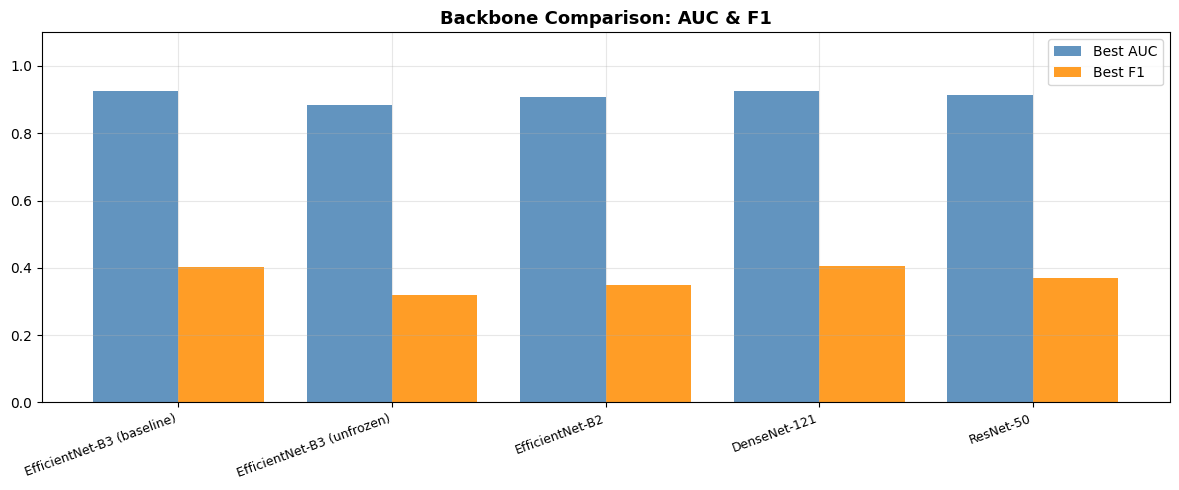

✅ backbone_comparison.png saved


In [71]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Plot Backbone Comparison
# ═══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
x      = range(len(bb_results))
labels = [r['Model'] for r in bb_results]

ax.bar(x,           [r['Best AUC'] for r in bb_results], width=0.4, label='Best AUC', color='steelblue', alpha=0.85)
ax.bar([i+0.4 for i in x], [r['Best F1'] for r in bb_results], width=0.4, label='Best F1', color='darkorange', alpha=0.85)
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Backbone Comparison: AUC & F1', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(str(M3_OUT/'backbone_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ backbone_comparison.png saved')

In [72]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Load Best Clf Model & Full Per-class Evaluation
# ═══════════════════════════════════════════════════════════════
gc.collect(); torch.cuda.empty_cache()

# Load best checkpoint from Milestone 2
ckpt     = torch.load(MODEL_DIR / 'best_efficientnet_b3.pth', map_location=DEV_STR)
best_clf = build_model('efficientnet_b3', NUM_CLASSES).to(DEV_STR)
best_clf.load_state_dict(ckpt['model_state'])
best_clf.eval()
print(f'Loaded checkpoint  epoch={ckpt["epoch"]}  AUC={ckpt["val_auc"]:.4f}')

_, vl = make_loaders(train_df, val_df, img_size=IMG_SIZE, batch=BATCH_SIZE)
crit   = get_criterion(train_df, DEV_STR)
_, _, _, all_probs, all_labels = eval_one_epoch(best_clf, vl, crit, DEV_STR)
preds  = (all_probs >= 0.5).astype(int)

# ── Per-class full metrics ─────────────────────────────────────
print('\nFull Per-class Evaluation:')
print('-'*65)
eval_rows = []
for i, cls in enumerate(PATHOLOGY_CLASSES):
    if all_labels[:,i].sum() == 0: continue
    auc  = roc_auc_score(all_labels[:,i], all_probs[:,i])
    f1   = f1_score(all_labels[:,i], preds[:,i], zero_division=0)
    prec = precision_score(all_labels[:,i], preds[:,i], zero_division=0)
    rec  = recall_score(all_labels[:,i], preds[:,i], zero_division=0)
    eval_rows.append({'Class':cls, 'AUC':round(auc,4), 'F1':round(f1,4),
                      'Precision':round(prec,4), 'Recall':round(rec,4)})
    print(f'  {cls:<35} AUC={auc:.4f}  F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}')

clf_eval_df = pd.DataFrame(eval_rows)
print(f'\n  Mean AUC       : {clf_eval_df["AUC"].mean():.4f}')
print(f'  Mean F1        : {clf_eval_df["F1"].mean():.4f}')
print(f'  Mean Precision : {clf_eval_df["Precision"].mean():.4f}')
print(f'  Mean Recall    : {clf_eval_df["Recall"].mean():.4f}')
clf_eval_df.to_csv(str(M3_OUT/'clf_full_evaluation.csv'), index=False)
print('\n✅ clf_full_evaluation.csv saved')

Loaded checkpoint  epoch=6  AUC=0.9207

Full Per-class Evaluation:
-----------------------------------------------------------------
  Aortic enlargement                  AUC=0.9649  F1=0.7683  P=0.7159  R=0.8289
  Atelectasis                         AUC=0.9681  F1=0.2222  P=0.1364  R=0.6000
  Calcification                       AUC=0.8965  F1=0.2034  P=0.1250  R=0.5455
  Cardiomegaly                        AUC=0.9602  F1=0.6939  P=0.6220  R=0.7846
  Consolidation                       AUC=0.9432  F1=0.4000  P=0.3043  R=0.5833
  ILD                                 AUC=0.8910  F1=0.2553  P=0.1622  R=0.6000
  Infiltration                        AUC=0.8946  F1=0.2182  P=0.1333  R=0.6000
  Lung Opacity                        AUC=0.9324  F1=0.4884  P=0.3818  R=0.6774
  Nodule/Mass                         AUC=0.9089  F1=0.3333  P=0.2264  R=0.6316
  Other lesion                        AUC=0.8860  F1=0.3855  P=0.2712  R=0.6667
  Pleural effusion                    AUC=0.9236  F1=0.3478  P=0.22

In [73]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — Detection Full Evaluation & Comparison Table
# ═══════════════════════════════════════════════════════════════
best_yolo = YOLO('/kaggle/working/yolo_runs/cliniscan_detection/weights/best.pt')
vm = best_yolo.val(data=str(DET_YAML), imgsz=640, batch=8,
                   conf=0.001, iou=0.5, device=DEVICE, verbose=True, split='val')

map50   = round(float(vm.box.map50), 4)
map5095 = round(float(vm.box.map),   4)
prec    = round(float(vm.box.mp),    4)
recall  = round(float(vm.box.mr),    4)

# ── Baseline vs Best comparison table ─────────────────────────
comparison = pd.DataFrame({
    'Model'          : ['EfficientNet-B3', 'EfficientNet-B3', 'YOLOv8m', 'YOLOv8m', 'YOLOv8m', 'YOLOv8m'],
    'Metric'         : ['AUC', 'F1', 'mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Baseline (M2)'  : [0.9205, 0.3711, 0.1301, 0.0556, 0.4160, 0.1300],
    'Best (M3)'      : [
        round(clf_eval_df['AUC'].mean(),4),
        round(clf_eval_df['F1'].mean(),4),
        map50, map5095, prec, recall
    ]
})
comparison['Improved'] = comparison.apply(
    lambda r: '✅' if r['Best (M3)'] > r['Baseline (M2)'] else '❌', axis=1
)
print('\n📊 Baseline vs Best Comparison Table:')
print(comparison.to_string(index=False))
comparison.to_csv(str(M3_OUT/'baseline_vs_m3_comparison.csv'), index=False)
print('\n✅ baseline_vs_m3_comparison.csv saved')

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,847,866 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2611.1±435.4 MB/s, size: 156.9 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 402 images, 299 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 402/402 168.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 3.7it/s 13.8s0.3s
                   all        402        789      0.416       0.13       0.13     0.0556
    Aortic enlargement         78        187      0.635      0.412      0.491      0.249
           Atelectasis          3          3          0          0     0.0258    0.00569
         Calcification          9         12          1          0          0          0
          Cardiomegaly         65        160      0.809      0.318      0.519      0.279
         Consolidation          8 

In [74]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — Grad-CAM Implementation
# ═══════════════════════════════════════════════════════════════
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None
        self.acts  = None
        target_layer.register_forward_hook(lambda m,i,o: setattr(self,'acts',o.detach()))
        target_layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'grads',go[0].detach()))

    def generate(self, tensor, class_idx):
        self.model.eval()
        out = self.model(tensor)
        self.model.zero_grad()
        out[0, class_idx].backward()
        w   = self.grads[0].mean(dim=(1,2))
        cam = (w[:,None,None] * self.acts[0]).sum(0)
        cam = torch.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy()

# Hook last conv block
target_layer = best_clf.features[-1]
gradcam      = GradCAM(best_clf, target_layer)
_, val_tf    = make_transforms(IMG_SIZE)
print('GradCAM ready ✅')

GradCAM ready ✅


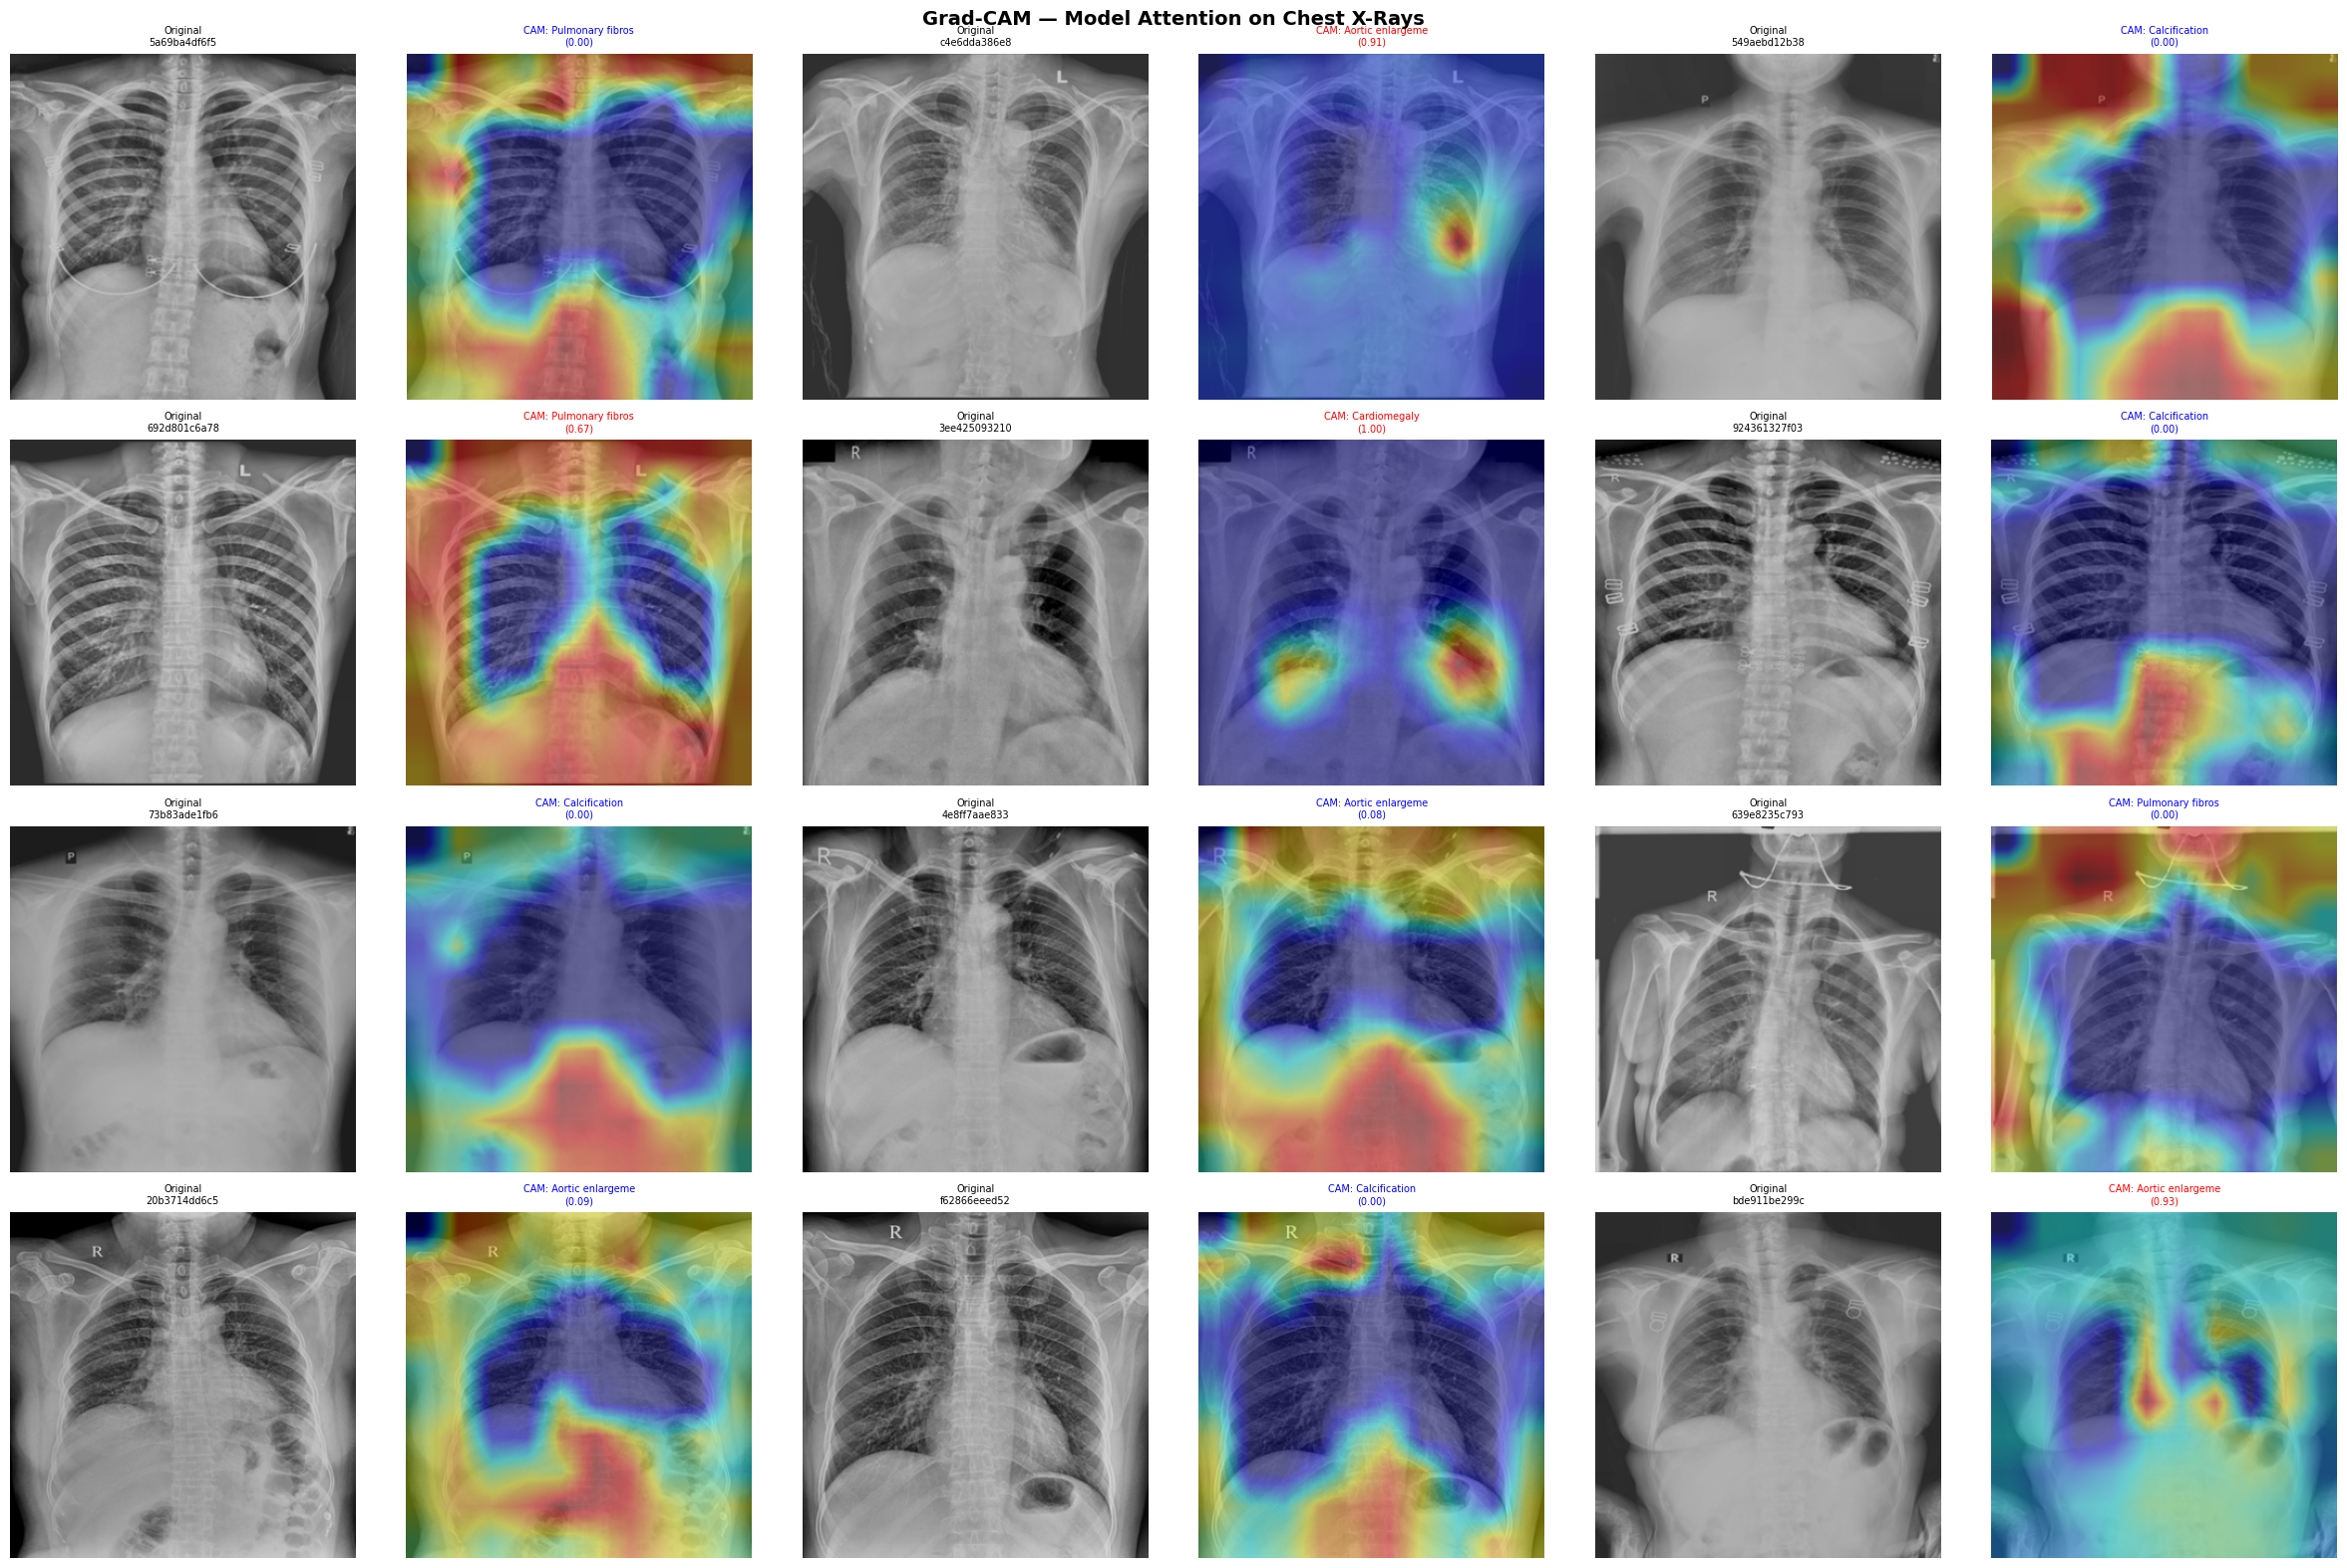

✅ gradcam_heatmaps.png saved
✅ Per-class Grad-CAM saved → /kaggle/working/milestone3/gradcam


In [75]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — Generate & Save Grad-CAM Heatmaps
# ═══════════════════════════════════════════════════════════════
GCAM_DIR = M3_OUT / 'gradcam'; GCAM_DIR.mkdir(exist_ok=True)

sample_imgs = list(VAL_PNG.glob('*.png'))[:12]
fig, axes   = plt.subplots(4, 6, figsize=(24, 16))

for idx, img_path in enumerate(sample_imgs):
    img_pil = Image.open(img_path).convert('RGB')
    tensor  = val_tf(img_pil).unsqueeze(0).to(DEV_STR)

    # Get top predicted class
    with torch.no_grad():
        probs = torch.sigmoid(best_clf(tensor)).squeeze().cpu().numpy()
    top_cls  = int(np.argmax(probs))
    top_prob = probs[top_cls]

    # Generate CAM
    t2  = val_tf(img_pil).unsqueeze(0).to(DEV_STR).requires_grad_(True)
    cam = gradcam.generate(t2, top_cls)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Overlay
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    overlay = (0.6*img_np + 0.4*heatmap).astype(np.uint8)

    r_orig, c_orig = divmod(idx*2,   6)
    r_heat, c_heat = divmod(idx*2+1, 6)

    axes[r_orig][c_orig].imshow(img_np, cmap='gray')
    axes[r_orig][c_orig].set_title(f'Original\n{img_path.stem[:12]}', fontsize=7); axes[r_orig][c_orig].axis('off')
    axes[r_heat][c_heat].imshow(overlay)
    axes[r_heat][c_heat].set_title(f'CAM: {PATHOLOGY_CLASSES[top_cls][:16]}\n({top_prob:.2f})',
                                    fontsize=7, color='red' if top_prob>=0.5 else 'blue')
    axes[r_heat][c_heat].axis('off')

plt.suptitle('Grad-CAM — Model Attention on Chest X-Rays', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(M3_OUT/'gradcam_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ gradcam_heatmaps.png saved')

# ── Save per-class examples ────────────────────────────────────
for cls_idx, cls_name in enumerate(PATHOLOGY_CLASSES):
    found = 0
    for img_path in list(VAL_PNG.glob('*.png')):
        if found >= 2: break
        img_pil = Image.open(img_path).convert('RGB')
        t       = val_tf(img_pil).unsqueeze(0).to(DEV_STR)
        with torch.no_grad():
            prob = torch.sigmoid(best_clf(t)).squeeze()[cls_idx].item()
        if prob < 0.4: continue
        cam     = gradcam.generate(t.requires_grad_(True), cls_idx)
        cam     = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heatmap = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
        img_np  = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        overlay = (0.6*img_np + 0.4*heatmap).astype(np.uint8)
        fig, ax = plt.subplots(1,2,figsize=(10,4))
        ax[0].imshow(img_np, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
        ax[1].imshow(overlay); ax[1].set_title(f'{cls_name} ({prob:.2f})'); ax[1].axis('off')
        plt.suptitle(f'Grad-CAM: {cls_name}', fontweight='bold')
        plt.tight_layout()
        safe = cls_name.replace('/','_').replace(' ','_')
        plt.savefig(str(GCAM_DIR/f'{safe}_{found+1}.png'), dpi=100, bbox_inches='tight')
        plt.close(); found += 1

print(f'✅ Per-class Grad-CAM saved → {GCAM_DIR}')

True Positives  : 253
False Positives : 432  ← wrong detections
False Negatives : 108  ← missed findings

Per-class Error Breakdown:
------------------------------------------------------------
  Aortic enlargement                  TP= 63  FP= 25  FN= 13  Miss=0.17
  Atelectasis                         TP=  3  FP= 19  FN=  2  Miss=0.40
  Calcification                       TP=  6  FP= 42  FN=  5  Miss=0.45
  Cardiomegaly                        TP= 51  FP= 31  FN= 14  Miss=0.22
  Consolidation                       TP=  7  FP= 16  FN=  5  Miss=0.42
  ILD                                 TP=  6  FP= 31  FN=  4  Miss=0.40
  Infiltration                        TP=  6  FP= 39  FN=  4  Miss=0.40
  Lung Opacity                        TP= 21  FP= 34  FN= 10  Miss=0.32
  Nodule/Mass                         TP= 12  FP= 41  FN=  7  Miss=0.37
  Other lesion                        TP= 16  FP= 43  FN=  8  Miss=0.33
  Pleural effusion                    TP= 12  FP= 42  FN=  3  Miss=0.20
  Pleural thic

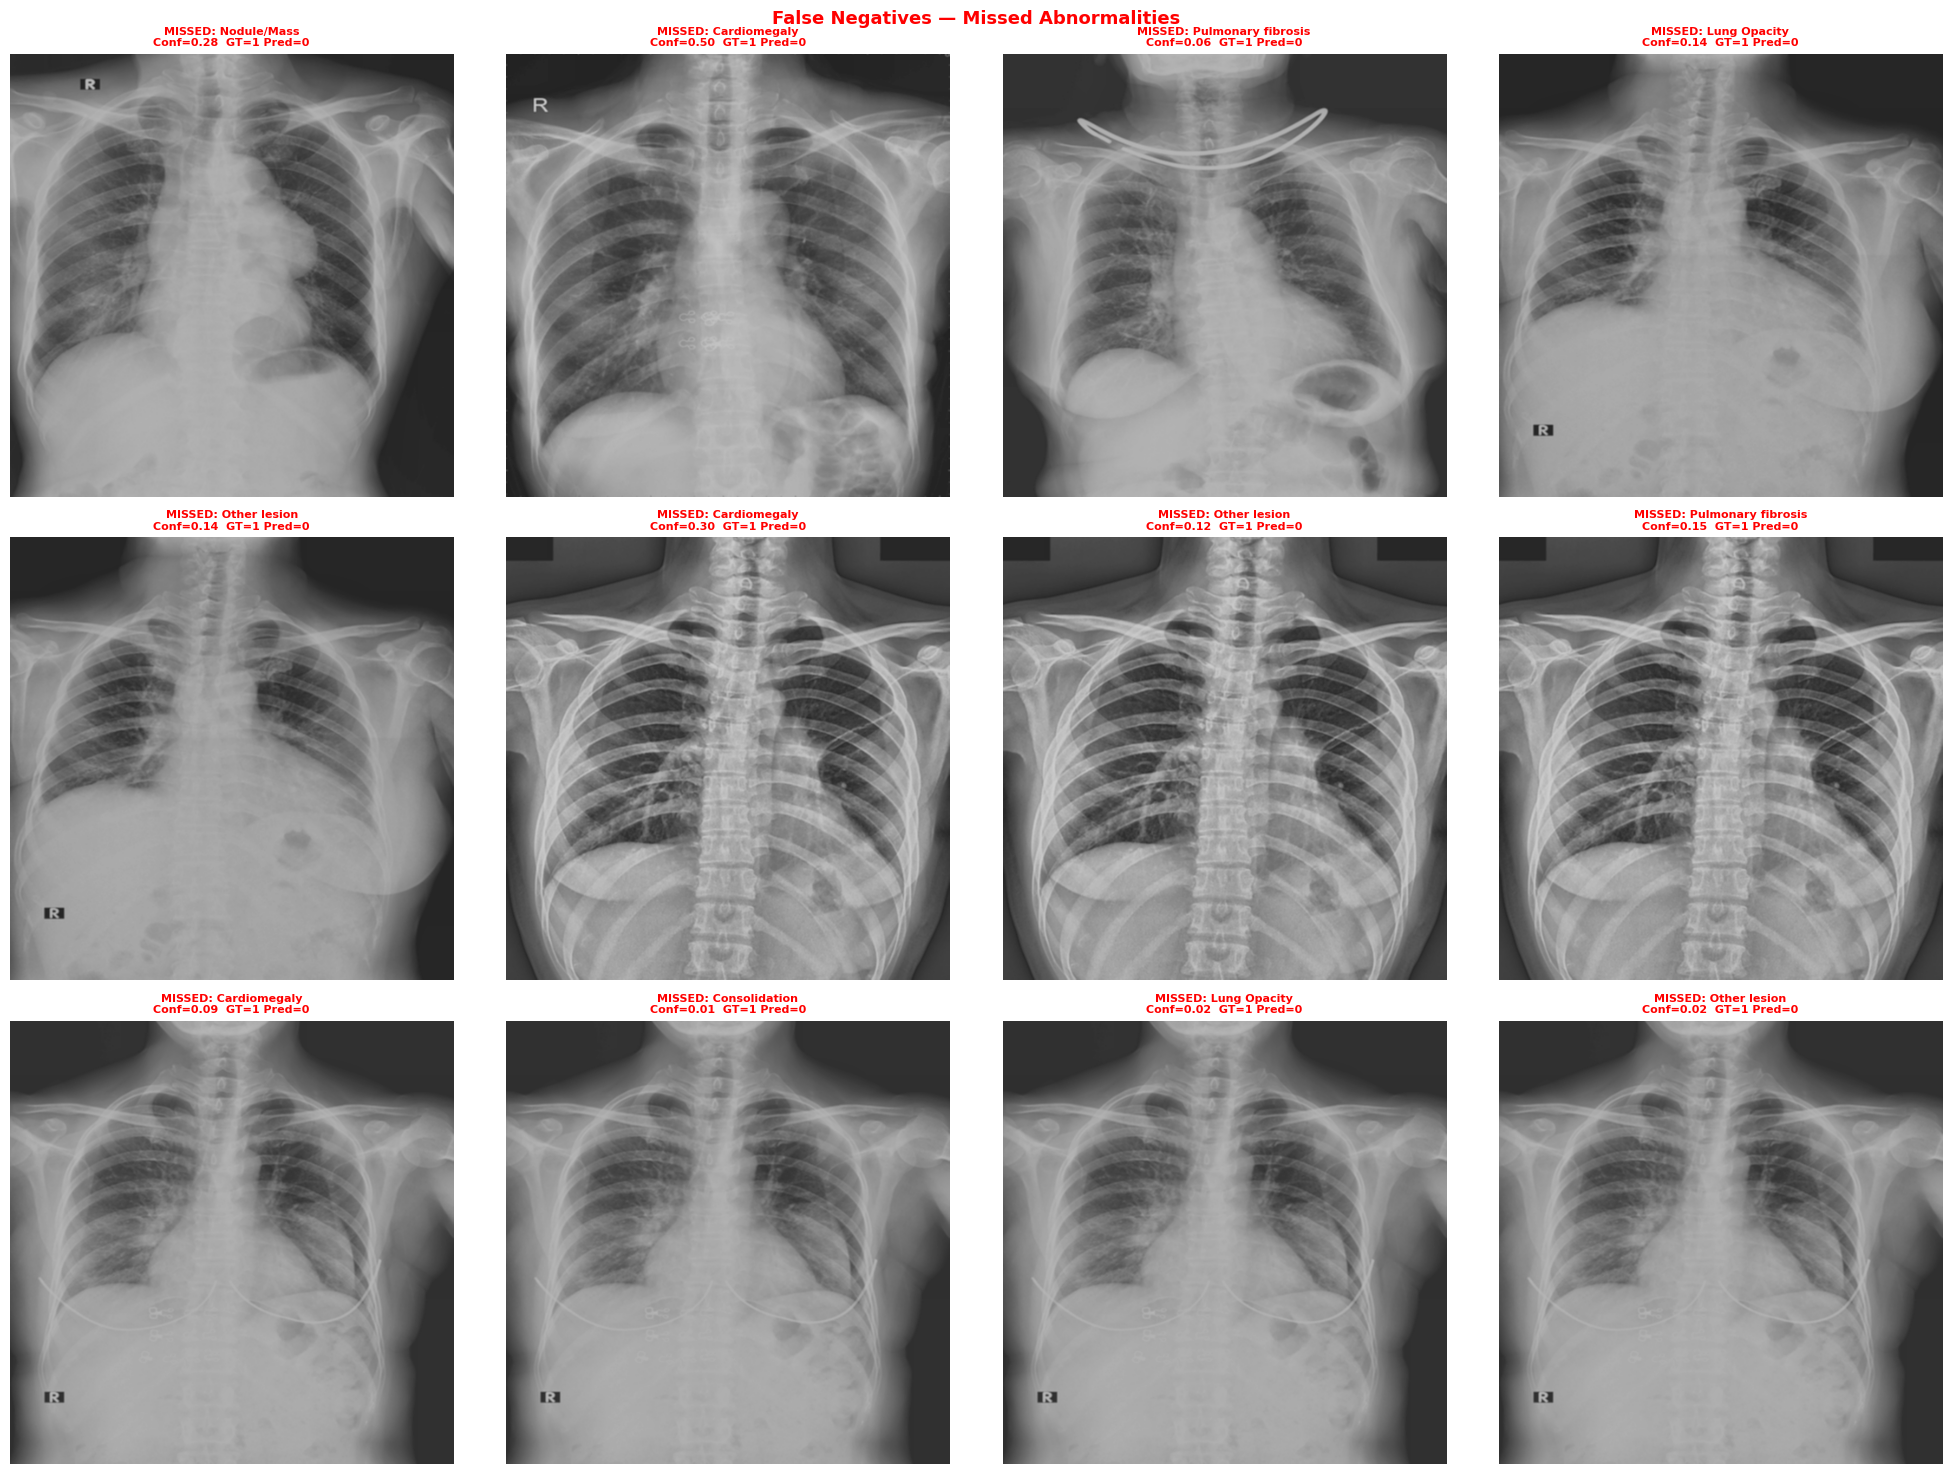

✅ false_negatives.png saved


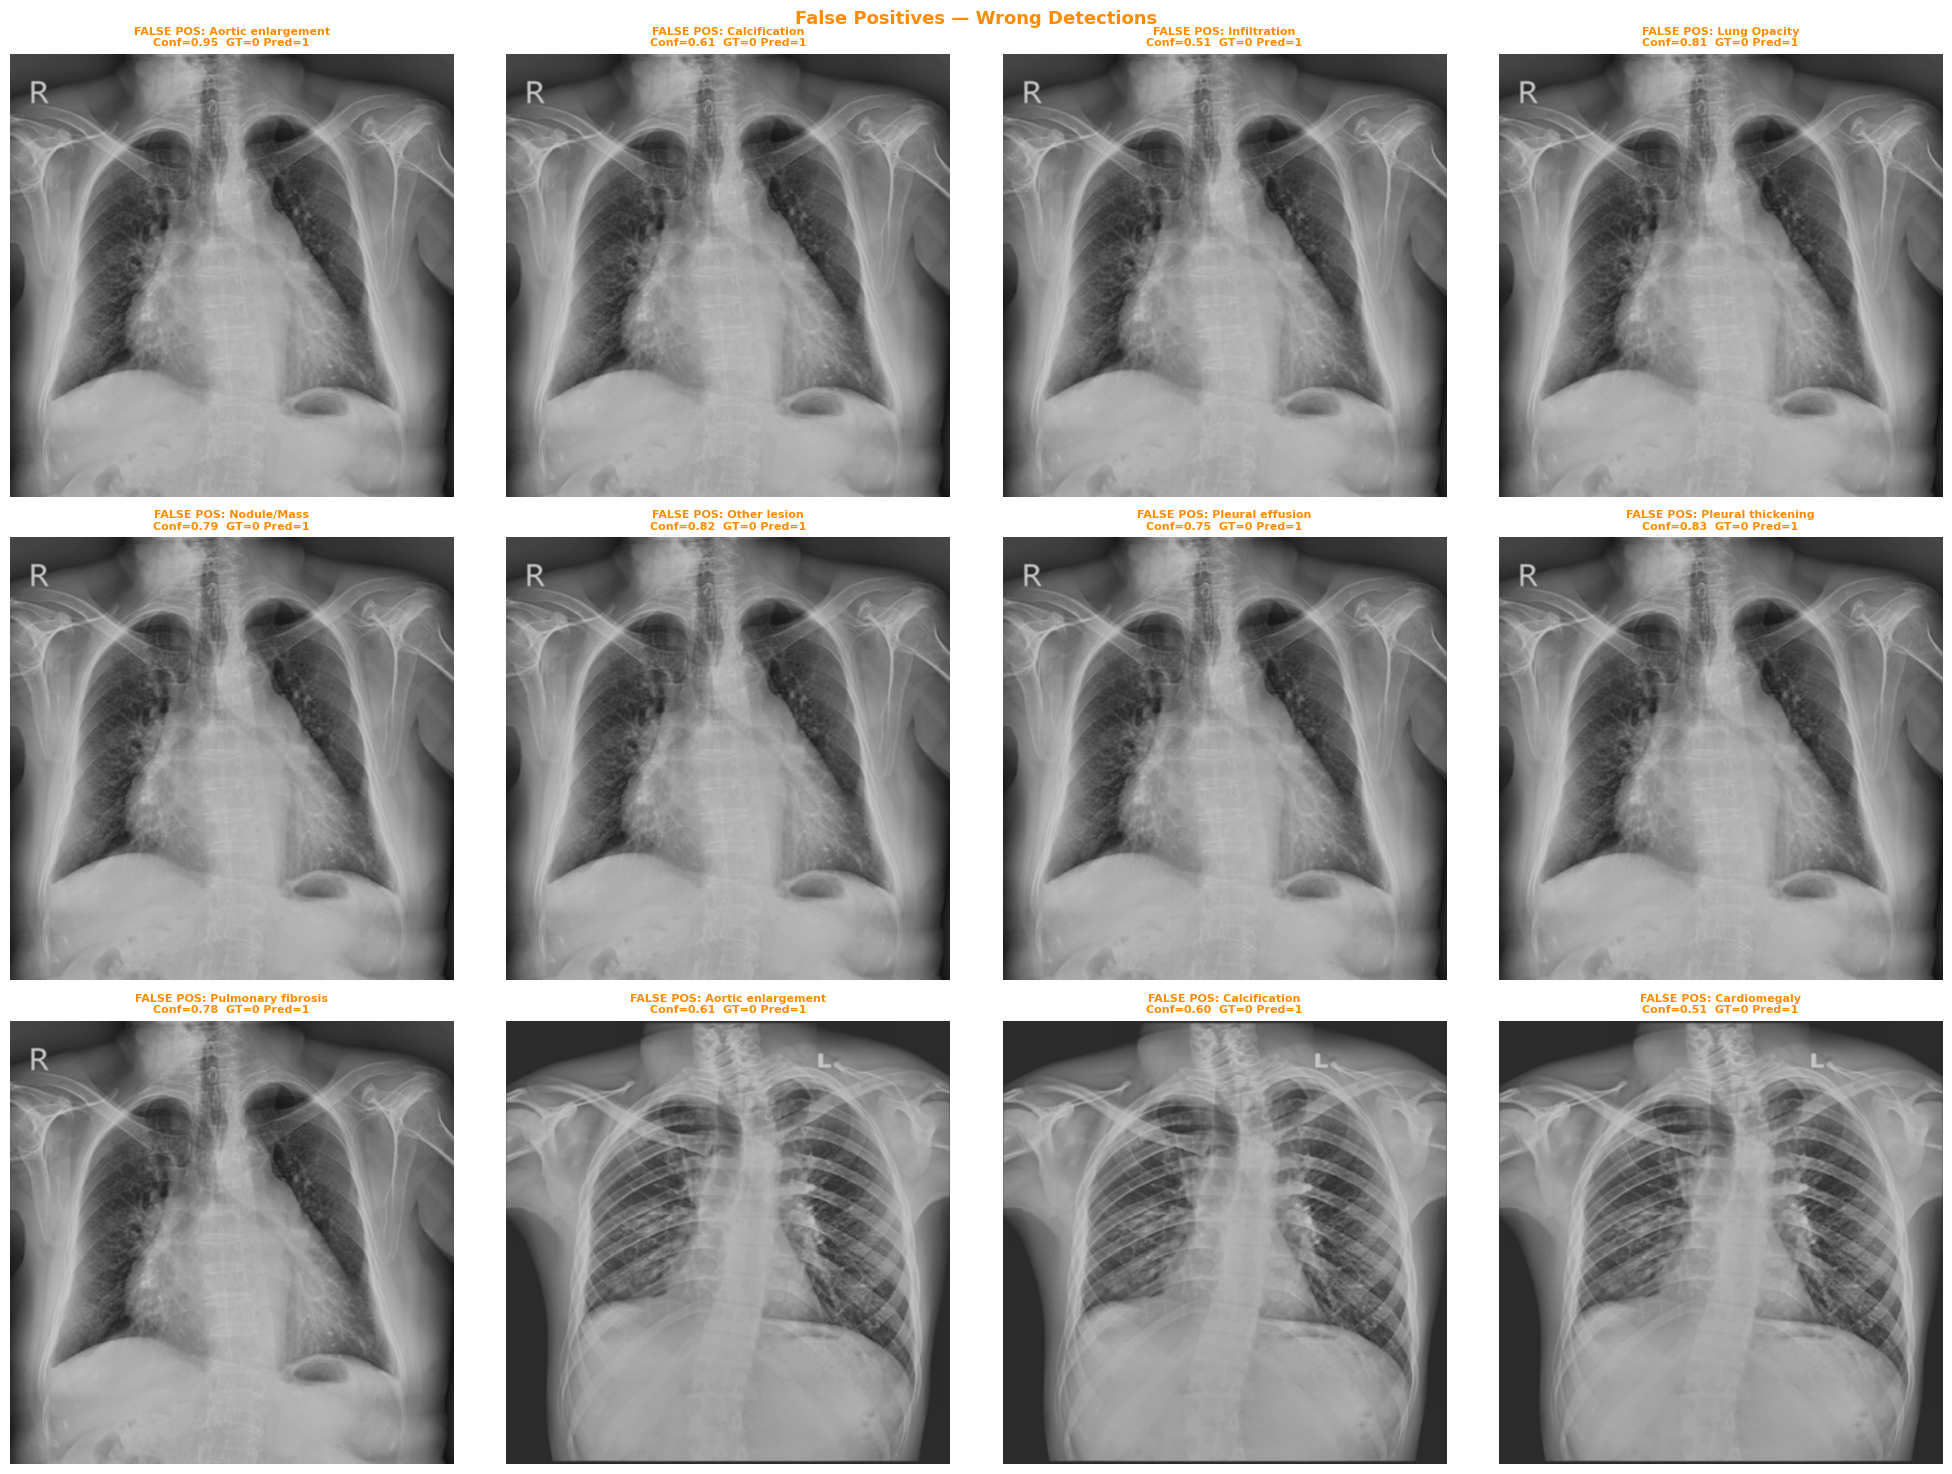

✅ false_positives.png saved


In [76]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — Classification Error Analysis
# ═══════════════════════════════════════════════════════════════
ERR_DIR = M3_OUT / 'error_analysis'; ERR_DIR.mkdir(exist_ok=True)

TP_list, FP_list, FN_list = [], [], []
for i in range(len(val_df)):
    for c in range(NUM_CLASSES):
        gt, pred = int(all_labels[i,c]), int(preds[i,c])
        if pred==1 and gt==1: TP_list.append((i,c, all_probs[i,c]))
        elif pred==1 and gt==0: FP_list.append((i,c, all_probs[i,c]))
        elif pred==0 and gt==1: FN_list.append((i,c, all_probs[i,c]))

print(f'True Positives  : {len(TP_list):,}')
print(f'False Positives : {len(FP_list):,}  ← wrong detections')
print(f'False Negatives : {len(FN_list):,}  ← missed findings')

# ── Per-class breakdown ────────────────────────────────────────
print('\nPer-class Error Breakdown:')
print('-'*60)
err_rows = []
for c, cls in enumerate(PATHOLOGY_CLASSES):
    tp = sum(1 for _,ci,_ in TP_list if ci==c)
    fp = sum(1 for _,ci,_ in FP_list if ci==c)
    fn = sum(1 for _,ci,_ in FN_list if ci==c)
    total_gt = int(all_labels[:,c].sum())
    miss_rate = fn/(total_gt+1e-6)
    fp_rate   = fp/(fp+tp+1e-6)
    err_rows.append({'Class':cls,'TP':tp,'FP':fp,'FN':fn,
                     'GT':total_gt,'MissRate':round(miss_rate,3),'FPRate':round(fp_rate,3)})
    print(f'  {cls:<35} TP={tp:3d}  FP={fp:3d}  FN={fn:3d}  Miss={miss_rate:.2f}')

err_df = pd.DataFrame(err_rows).sort_values('MissRate', ascending=False)
err_df.to_csv(str(M3_OUT/'error_analysis.csv'), index=False)

# ── Visualize False Negatives ──────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
shown = 0
for img_idx, cls_idx, prob in FN_list[:12]:
    if shown >= 12: break
    row  = val_df.iloc[img_idx]
    img  = np.array(Image.open(row['image_path']).convert('RGB'))
    r,c2 = divmod(shown, 4)
    axes[r][c2].imshow(img, cmap='gray')
    axes[r][c2].set_title(f'MISSED: {PATHOLOGY_CLASSES[cls_idx][:18]}\nConf={prob:.2f}  GT=1 Pred=0',
                           fontsize=8, color='red', fontweight='bold')
    axes[r][c2].axis('off'); shown += 1
for j in range(shown,12):
    r,c2=divmod(j,4); axes[r][c2].axis('off')
plt.suptitle('False Negatives — Missed Abnormalities', fontsize=13, fontweight='bold', color='red')
plt.tight_layout()
plt.savefig(str(ERR_DIR/'false_negatives.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ false_negatives.png saved')

# ── Visualize False Positives ─────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
shown = 0
for img_idx, cls_idx, prob in FP_list[:12]:
    if shown >= 12: break
    row  = val_df.iloc[img_idx]
    img  = np.array(Image.open(row['image_path']).convert('RGB'))
    r,c2 = divmod(shown, 4)
    axes[r][c2].imshow(img, cmap='gray')
    axes[r][c2].set_title(f'FALSE POS: {PATHOLOGY_CLASSES[cls_idx][:18]}\nConf={prob:.2f}  GT=0 Pred=1',
                           fontsize=8, color='darkorange', fontweight='bold')
    axes[r][c2].axis('off'); shown += 1
for j in range(shown,12):
    r,c2=divmod(j,4); axes[r][c2].axis('off')
plt.suptitle('False Positives — Wrong Detections', fontsize=13, fontweight='bold', color='darkorange')
plt.tight_layout()
plt.savefig(str(ERR_DIR/'false_positives.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ false_positives.png saved')

YOLO Detection Error Analysis...


YOLO errors:   0%|          | 0/200 [00:00<?, ?it/s]

Correct detections : 59
Missed             : 108
False detections   : 11

Top missed classes:
  Pleural thickening                  17
  Lung Opacity                        14
  Pulmonary fibrosis                  14
  Cardiomegaly                        12
  Aortic enlargement                  10


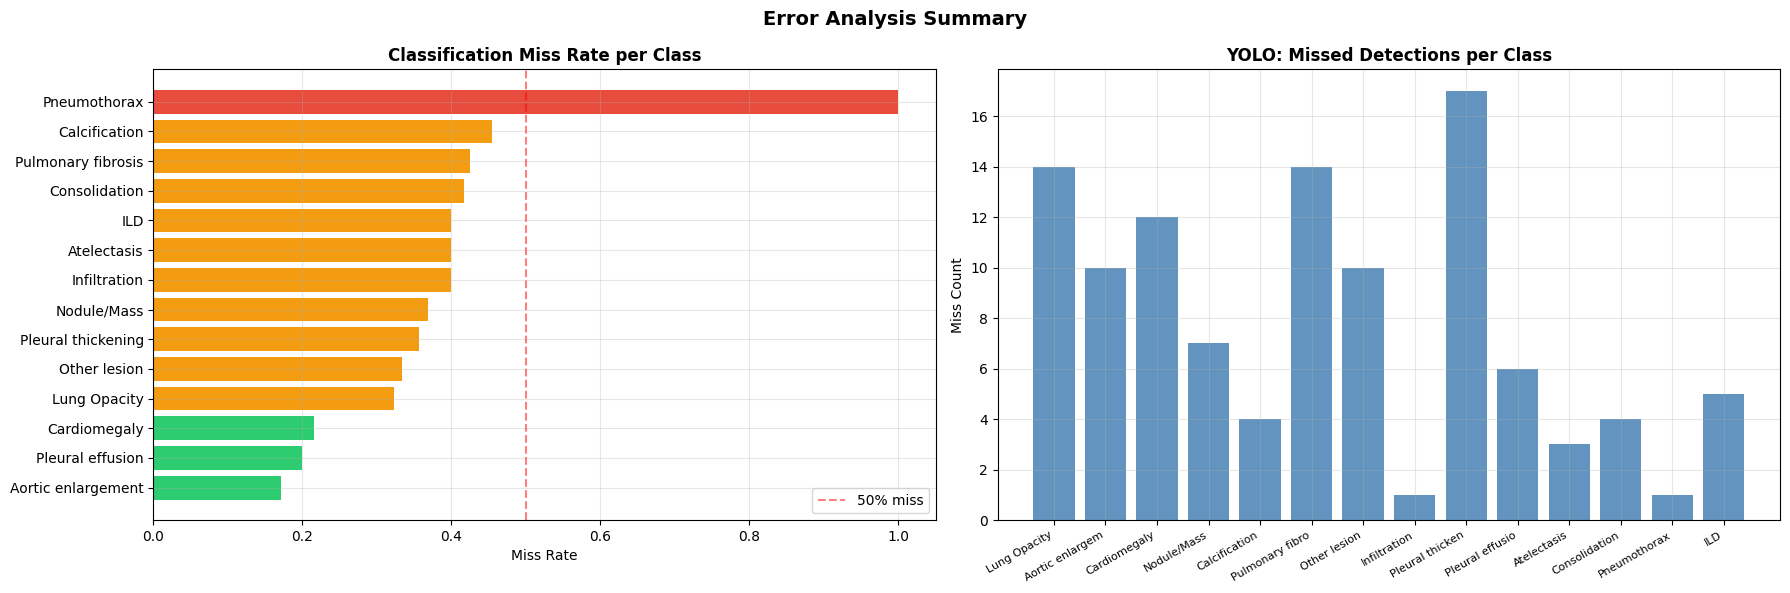

✅ error_summary.png saved


In [77]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — YOLO Error Analysis + Error Summary Chart
# ═══════════════════════════════════════════════════════════════
print('YOLO Detection Error Analysis...')
yolo_correct, yolo_missed, yolo_false = [], [], []

for img_path in tqdm(list(DIMG_VAL.glob('*.png'))[:200], desc='YOLO errors'):
    lbl_path = DLBL_VAL / (img_path.stem+'.txt')
    if not lbl_path.exists(): continue
    gt_cls = [int(l.split()[0]) for l in lbl_path.read_text().strip().split('\n') if l.strip()]
    if not gt_cls: continue
    det = best_yolo.predict(source=str(img_path), imgsz=640, conf=0.15,
                            iou=0.45, device=DEVICE, verbose=False)[0]
    pred_cls = det.boxes.cls.cpu().numpy().astype(int).tolist() if det.boxes and len(det.boxes)>0 else []
    yolo_correct.extend(list(set(pred_cls) & set(gt_cls)))
    yolo_missed.extend(list(set(gt_cls)   - set(pred_cls)))
    yolo_false.extend(list(set(pred_cls)  - set(gt_cls)))

print(f'Correct detections : {len(yolo_correct):,}')
print(f'Missed             : {len(yolo_missed):,}')
print(f'False detections   : {len(yolo_false):,}')

missed_by_cls = Counter(yolo_missed)
print('\nTop missed classes:')
for cid, cnt in missed_by_cls.most_common(5):
    print(f'  {PATHOLOGY_CLASSES[cid]:<35} {cnt}')

# ── Summary chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

err_sorted = err_df.sort_values('MissRate')
axes[0].barh(err_sorted['Class'], err_sorted['MissRate'],
             color=['#e74c3c' if v>0.5 else '#f39c12' if v>0.3 else '#2ecc71'
                    for v in err_sorted['MissRate']])
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% miss')
axes[0].set_title('Classification Miss Rate per Class', fontweight='bold')
axes[0].set_xlabel('Miss Rate'); axes[0].legend(); axes[0].grid(alpha=0.3)

if missed_by_cls:
    mc = [PATHOLOGY_CLASSES[k][:15] for k in missed_by_cls]
    axes[1].bar(range(len(mc)), list(missed_by_cls.values()), color='steelblue', alpha=0.85)
    axes[1].set_xticks(range(len(mc)))
    axes[1].set_xticklabels(mc, rotation=30, ha='right', fontsize=8)
    axes[1].set_title('YOLO: Missed Detections per Class', fontweight='bold')
    axes[1].set_ylabel('Miss Count'); axes[1].grid(alpha=0.3)

plt.suptitle('Error Analysis Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(ERR_DIR/'error_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ error_summary.png saved')

In [78]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — Final Summary
# ═══════════════════════════════════════════════════════════════
print('\n' + '='*65)
print('  🏁  MILESTONE 3 — FINAL SUMMARY')
print('='*65)

print('\n📋 TASK 1 — Hyperparameter Tuning:')
if clf_exp_results:
    best_exp = max(clf_exp_results, key=lambda x: x['Best AUC'])
    print(f'  Best clf config : {best_exp["Experiment"]}')
    print(f'  Best AUC        : {best_exp["Best AUC"]}')
if yolo_exp_results:
    best_yolo_exp = max(yolo_exp_results, key=lambda x: x['mAP@50'])
    print(f'  Best YOLO config: {best_yolo_exp["Experiment"]}')
    print(f'  Best mAP@50     : {best_yolo_exp["mAP@50"]}')

print('\n🔬 TASK 2 — Albumentations:')
print(f'  AUC with Albumentations : {best_albu_auc:.4f}')

print('\n🧠 TASK 3 — Transfer Learning:')
print(bb_df[['Model','Best AUC','Best F1']].to_string(index=False))

print('\n📊 TASK 4 — Full Evaluation:')
print(comparison[['Metric','Baseline (M2)','Best (M3)','Improved']].to_string(index=False))

print('\n🔥 TASK 5 — Grad-CAM:')
print(f'  Heatmaps saved : {M3_OUT}/gradcam/')

print('\n🔍 TASK 6 — Error Analysis:')
print(f'  False Negatives : {len(FN_list):,}')
print(f'  False Positives : {len(FP_list):,}')
print(f'  Most missed     : {err_df.iloc[0]["Class"]}')

print('\n📁 All output files:')
for f in sorted(M3_OUT.rglob('*')):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size/1e6:.2f} MB')
print('='*65)


  🏁  MILESTONE 3 — FINAL SUMMARY

📋 TASK 1 — Hyperparameter Tuning:
  Best clf config : Large bs  AdamW bs=8
  Best AUC        : 0.9221
  Best YOLO config: High IoU  iou=0.60
  Best mAP@50     : 0.1067

🔬 TASK 2 — Albumentations:
  AUC with Albumentations : 0.9075

🧠 TASK 3 — Transfer Learning:
                     Model  Best AUC  Best F1
EfficientNet-B3 (baseline)    0.9252   0.4033
              DenseNet-121    0.9252   0.4064
                 ResNet-50    0.9127   0.3705
           EfficientNet-B2    0.9087   0.3504
EfficientNet-B3 (unfrozen)    0.8845   0.3181

📊 TASK 4 — Full Evaluation:
   Metric  Baseline (M2)  Best (M3) Improved
      AUC         0.9205     0.9207        ✅
       F1         0.3711     0.3794        ✅
   mAP@50         0.1301     0.1301        ❌
mAP@50-95         0.0556     0.0556        ❌
Precision         0.4160     0.4160        ❌
   Recall         0.1300     0.1300        ❌

🔥 TASK 5 — Grad-CAM:
  Heatmaps saved : /kaggle/working/milestone3/gradcam/

🔍 TAS